# Cardiovascular Disease Prediction Using Machine Learning

This Jupyter notebook is an adaptation of the original work on heart disease detection found in the GitHub repository: [Heart-Disease-ML-Explainer](https://github.com/rasnarim/Heart-Disease-ML-Explainer). In that notebook, a structured workflow was used to analyze and model heart disease detection. 

In this notebook, we will follow a similar methodology but apply it to a different dataset sourced from Kaggle: [Cardiovascular Disease Dataset](https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset). 

The objective of this notebook is to develop and interpret machine learning models that predict the presence of cardiovascular disease based on the dataset's features. We will use tools for both model training and explainability to gain insights into feature importance and individual predictions.

## Workflow Outline:
1. **Data Loading and Exploration**: Load and inspect the dataset to understand its structure, features, and initial properties.
2. **Data Cleaning and Preprocessing**: Handle missing values, outliers, and transform data into a suitable format for machine learning.
3. **Exploratory Data Analysis (EDA)**: Visualize the dataset and uncover key patterns and relationships between features.
4. **Feature Importance Analysis with Decision Tree**: Train a Decision Tree model to analyze feature importance and identify key predictors.
5. **Logistic Regression on Top Features**: Build and evaluate a Logistic Regression model using the most important features.
6. **SHAP Model Interpretability**: Use SHAP (SHapley Additive exPlanations) to interpret the predictions of the Logistic Regression model.
7. **SHAP Force Plot Interpretation (Single Case)**: Create SHAP force plots to explain predictions for specific instances.

By the end of this notebook, we aim to not only build a robust predictive model but also understand the reasoning behind its predictions, aiding in transparent and actionable insights.


In [1]:
import os

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd

import shap

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay

import pickle


In [2]:


# Set a consistent style for plots
sns.set(style="whitegrid")


# Define the data path and file name
data_dir = 'data'
data_file = 'cardio_train_kaggle.csv'

# Ensure the directory exists
os.makedirs(data_dir, exist_ok=True)

# Assume the file is saved under the data directory after download
file_path = os.path.join(data_dir, data_file)

# Load the dataset
data = pd.read_csv(file_path, delimiter=';', index_col=0)

# Display basic information about the dataset
print("Shape of the dataset:", data.shape)
print("\nFirst 5 rows of the dataset:")
data.head()


Shape of the dataset: (70000, 12)

First 5 rows of the dataset:


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
id,,,,,,,,,,,,
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
# Load the dataset
data_path = "data/cardio_train_kaggle.csv"
df = pd.read_csv(data_path)

# Dataset Feature Description

The dataset consists of 12 features, including the target variable `cardio`. Below is a detailed description of each feature:

1. **Age** (`age`):  
   - **Type**: Objective Feature  
   - **Description**: The age of the individual in days.  
   - **Data Type**: Integer  

2. **Height** (`height`):  
   - **Type**: Objective Feature  
   - **Description**: The height of the individual in centimeters.  
   - **Data Type**: Integer  

3. **Weight** (`weight`):  
   - **Type**: Objective Feature  
   - **Description**: The weight of the individual in kilograms.  
   - **Data Type**: Float  

4. **Gender** (`gender`):  
   - **Type**: Objective Feature  
   - **Description**: The gender of the individual, represented as categorical codes:  
     - `1`: Male  
     - `2`: Female  
   - **Data Type**: Categorical  

5. **Systolic Blood Pressure** (`ap_hi`):  
   - **Type**: Examination Feature  
   - **Description**: The systolic blood pressure of the individual.  
   - **Data Type**: Integer  

6. **Diastolic Blood Pressure** (`ap_lo`):  
   - **Type**: Examination Feature  
   - **Description**: The diastolic blood pressure of the individual.  
   - **Data Type**: Integer  

7. **Cholesterol** (`cholesterol`):  
   - **Type**: Examination Feature  
   - **Description**: The cholesterol level of the individual, represented as categorical codes:  
     - `1`: Normal  
     - `2`: Above Normal  
     - `3`: Well Above Normal  
   - **Data Type**: Categorical  

8. **Glucose** (`gluc`):  
   - **Type**: Examination Feature  
   - **Description**: The glucose level of the individual, represented as categorical codes:  
     - `1`: Normal  
     - `2`: Above Normal  
     - `3`: Well Above Normal  
   - **Data Type**: Categorical  

9. **Smoking** (`smoke`):  
   - **Type**: Subjective Feature  
   - **Description**: Indicates whether the individual smokes or not.  
     - `0`: Non-Smoker  
     - `1`: Smoker  
   - **Data Type**: Binary  

10. **Alcohol Intake** (`alco`):  
    - **Type**: Subjective Feature  
    - **Description**: Indicates whether the individual consumes alcohol or not.  
      - `0`: Non-Drinker  
      - `1`: Drinker  
    - **Data Type**: Binary  

11. **Physical Activity** (`active`):  
    - **Type**: Subjective Feature  
    - **Description**: Indicates whether the individual engages in physical activity or not.  
      - `0`: Inactive  
      - `1`: Active  
    - **Data Type**: Binary  

12. **Cardiovascular Disease** (`cardio`):  
    - **Type**: Target Variable  
    - **Description**: Indicates the presence or absence of cardiovascular disease.  
      - `0`: No Cardiovascular Disease  
      - `1`: Cardiovascular Disease Present  
    - **Data Type**: Binary  


In [4]:
# Convert height to meters and calculate BMI
data['BMI'] = data['weight'] / ((data['height'] / 100) ** 2)  # Calculate BMI

# Drop the original height and weight columns
data.drop(columns=['height', 'weight'], inplace=True)

# Convert gender to binary (0 = Female, 1 = Male)
data['gender'] = data['gender'] - 1

# # Create new features based on blood pressure readings
# data['pulse_pressure'] = data['ap_hi'] - data['ap_lo']  # Pulse Pressure
# data['map'] = data['ap_lo'] + (data['pulse_pressure'] / 3)  # Mean Arterial Pressure (MAP)
# data['sys_dsys_ratio'] = data['ap_hi'] / data['ap_lo']  # Systolic-to-Diastolic Ratio

# # Display the first few rows to verify the new features
# print("New features (pulse_pressure, map, sys_dsys_ratio) added successfully!")
# print(data[['ap_hi', 'ap_lo', 'pulse_pressure', 'map', 'sys_dsys_ratio']].head())

# Display the first few rows to verify changes
print("BMI feature added and height/weight columns dropped successfully!")
data.head()



BMI feature added and height/weight columns dropped successfully!


,age,gender,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
id,,,,,,,,,,,
0,18393,1,110,80,1,1,0,0,1,0,21.967120
1,20228,0,140,90,3,1,0,0,1,1,34.927679
2,18857,0,130,70,3,1,0,0,0,1,23.507805
3,17623,1,150,100,1,1,0,0,1,1,28.710479
4,17474,0,100,60,1,1,0,0,0,0,23.011177


In [5]:
# Display dataset overview
print("Summary of dataset:")
print(data.info)

Summary of dataset:
<bound method DataFrame.info of          age  gender  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  active  \
id                                                                           
0      18393       1    110     80            1     1      0     0       1   
1      20228       0    140     90            3     1      0     0       1   
2      18857       0    130     70            3     1      0     0       0   
3      17623       1    150    100            1     1      0     0       1   
4      17474       0    100     60            1     1      0     0       0   
...      ...     ...    ...    ...          ...   ...    ...   ...     ...   
99993  19240       1    120     80            1     1      1     0       1   
99995  22601       0    140     90            2     2      0     0       1   
99996  19066       1    180     90            3     1      0     1       0   
99998  22431       0    135     80            1     2      0     0       0   
99999  20540

In [6]:
data.describe()

,age,gender,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,0.349571,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700,27.556513
std,2467.251667,0.476838,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003,6.091511
min,10798.000000,0.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.471784
25%,17664.000000,0.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,23.875115
50%,19703.000000,0.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,26.374068
75%,21327.000000,1.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,30.222222
max,23713.000000,1.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,298.666667


C:\Users\rasna\AppData\Local\Temp\ipykernel_14192\1753631311.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cardio', data=data, palette='viridis')


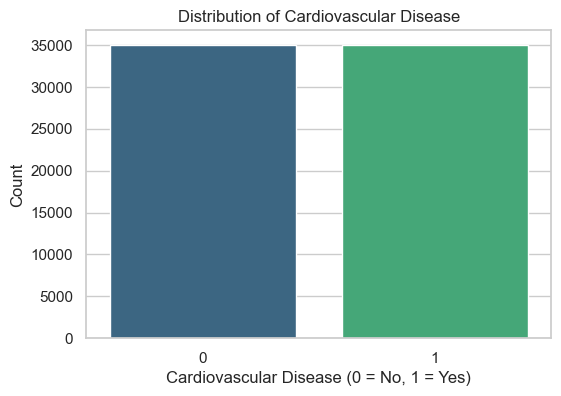

In [7]:
# Distribution of the target variable (cardio)
plt.figure(figsize=(6, 4))
sns.countplot(x='cardio', data=data, palette='viridis')
plt.title('Distribution of Cardiovascular Disease')
plt.xlabel('Cardiovascular Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


The target values have the same size so we don't need to be worried about inbalance in data. 

In [8]:
# # Plot histograms for numeric columns
# numeric_features = ['age', 'ap_hi', 'ap_lo', 'BMI']
# data[numeric_features].hist(bins=20, figsize=(12, 8), color='skyblue', edgecolor='black')
# plt.suptitle('Distributions of Numeric Features')
# plt.show()


In [9]:
# # Compute and plot the correlation matrix
# plt.figure(figsize=(10, 8))
# corr_matrix = data.corr()
# sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
# plt.title('Correlation Matrix')
# plt.show()


In [10]:
# # Compare BMI by gender
# plt.figure(figsize=(8, 6))
# sns.boxplot(x='gender', y='BMI', data=data, palette='Set2')
# plt.title('BMI Distribution by Gender')
# plt.xlabel('Gender (1 = Male, 2 = Female)')
# plt.ylabel('BMI')
# plt.show()


In [11]:
# # Pairplot for selected features
# selected_features = ['age', 'BMI', 'ap_hi', 'ap_lo', 'cardio']
# sns.pairplot(data[selected_features], hue='cardio', palette='husl')
# plt.suptitle('Pairplot of Selected Features', y=1.02)
# plt.show()


## Logistic Regression Model Training and Evaluation

In this section, we train a simple Logistic Regression model to predict the presence or absence of cardiovascular disease based on the features in the dataset. Logistic Regression is a widely used linear model for binary classification tasks.

### Steps Performed:
1. **Data Preparation**:
   - The dataset is split into features (`X`) and the target variable (`cardio`).
   - A 70-30 split is applied to divide the data into training and testing sets.

2. **Model Training**:
   - A Logistic Regression model is trained using the training data.
   - The model uses default parameters, with the maximum number of iterations set to 1000.

3. **Performance Evaluation**:
   - **Accuracy**: Measures the proportion of correct predictions.
   - **ROC-AUC**: Evaluates the model's ability to discriminate between classes.
   - **Classification Report**: Provides precision, recall, and F1-score for both classes.
   - **Confusion Matrix**: Visualizes true positives, true negatives, false positives, and false negatives.
   - **ROC Curve**: Shows the trade-off between sensitivity and specificity across different thresholds.



In [12]:
# Step 1: Prepare Data
X = data.drop(columns=['cardio'])  # Features
y = data['cardio']  # Target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X.head()

,age,gender,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,BMI
id,,,,,,,,,,
0,18393,1,110,80,1,1,0,0,1,21.967120
1,20228,0,140,90,3,1,0,0,1,34.927679
2,18857,0,130,70,3,1,0,0,0,23.507805
3,17623,1,150,100,1,1,0,0,1,28.710479
4,17474,0,100,60,1,1,0,0,0,23.011177


In [13]:
# Create a pipeline with StandardScaler and LogisticRegression
logistic_model = make_pipeline(StandardScaler(), LogisticRegression())

logistic_model.fit(X_train, y_train)

# Save the model to a file
with open('logistic_model_kaggle.pkl', 'wb') as f:
    pickle.dump(logistic_model, f)


In [14]:
# Step 3: Evaluate Performance
y_pred = logistic_model.predict(X_test)
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

In [15]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    """
    Evaluates a binary classification model and generates key metrics and visualizations.
    
    Parameters:
    - model: Trained binary classification model
    - X_train: Training features
    - y_train: Training target
    - X_test: Testing features
    - y_test: Testing target
    
    Outputs:
    - Prints accuracy, classification report, and ROC-AUC score.
    - Displays a confusion matrix and ROC curve.
    """
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    report = classification_report(y_test, y_pred)
    
    # Display metrics
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    print("\nClassification Report:\n", report)
    
    # Confusion Matrix
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
    plt.title('Confusion Matrix')
    plt.show()
    
    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'Model (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

Accuracy: 0.7124
ROC-AUC Score: 0.7764

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.75      0.72     10506
           1       0.73      0.67      0.70     10494

    accuracy                           0.71     21000
   macro avg       0.71      0.71      0.71     21000
weighted avg       0.71      0.71      0.71     21000



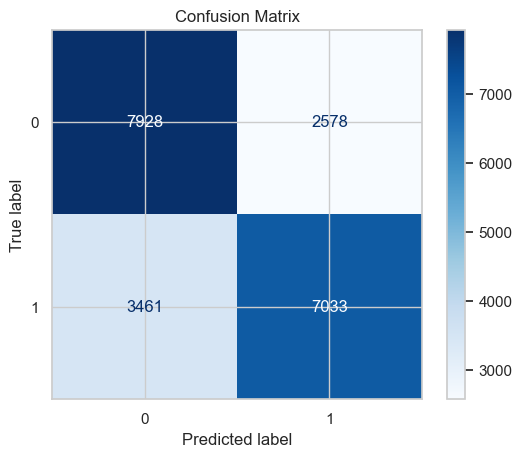

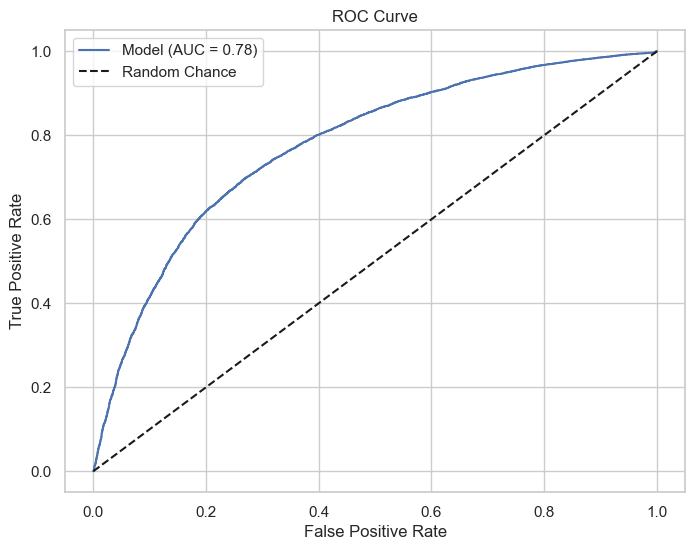

In [16]:
# Evaluate the model
evaluate_model(logistic_model, X_train, y_train, X_test, y_test)

In [17]:
data.columns


Index(['age', 'gender', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke',
       'alco', 'active', 'cardio', 'BMI'],
      dtype='object')

In [18]:
# Display the first few rows to verify
data.head()

,age,gender,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
id,,,,,,,,,,,
0,18393,1,110,80,1,1,0,0,1,0,21.967120
1,20228,0,140,90,3,1,0,0,1,1,34.927679
2,18857,0,130,70,3,1,0,0,0,1,23.507805
3,17623,1,150,100,1,1,0,0,1,1,28.710479
4,17474,0,100,60,1,1,0,0,0,0,23.011177


This feature engineering approach did not result in a significant improvement. Therefore, we will proceed with the original dataset.


## SHAP for Model Interpretability

SHAP (SHapley Additive exPlanations) is used to interpret the predictions of the logistic regression model. By calculating SHAP values, we can understand the contribution of each feature to the model’s predictions.

### Key Visualizations:
1. **Summary Plot**:
   - Shows the distribution of SHAP values across all features, indicating the most influential features in the model.
   - Highlights both the magnitude and direction of feature impacts.

2. **Bar Plot**:
   - Displays the overall importance of each feature based on the average absolute SHAP values.

3. **Force Plot**:
   - Explains a single prediction by visualizing how each feature contributes to moving the model's output away from the baseline prediction.

These visualizations provide actionable insights into the model's behavior, aiding in interpretability and trustworthiness.


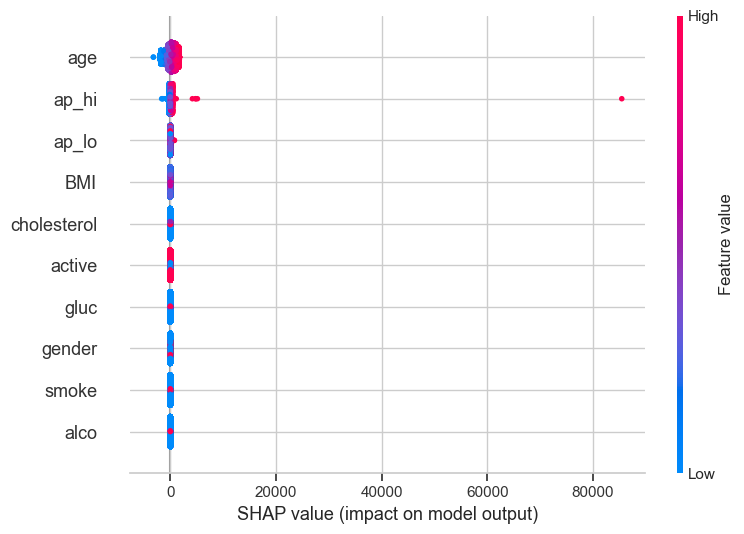

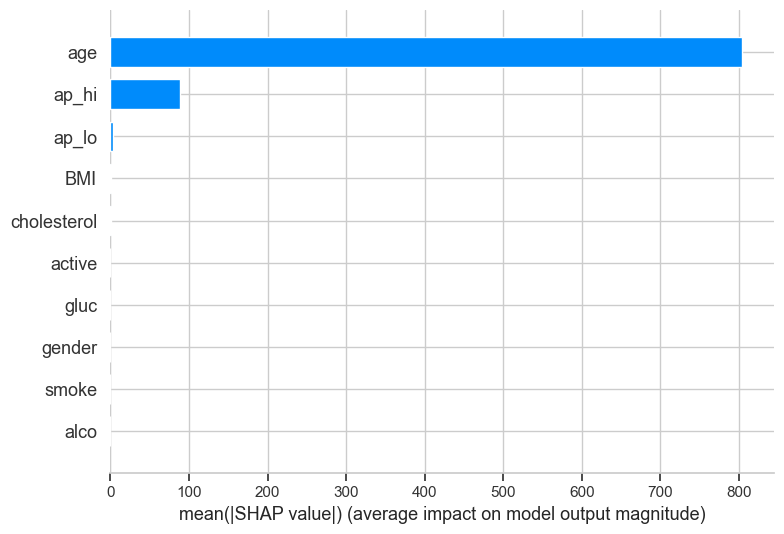

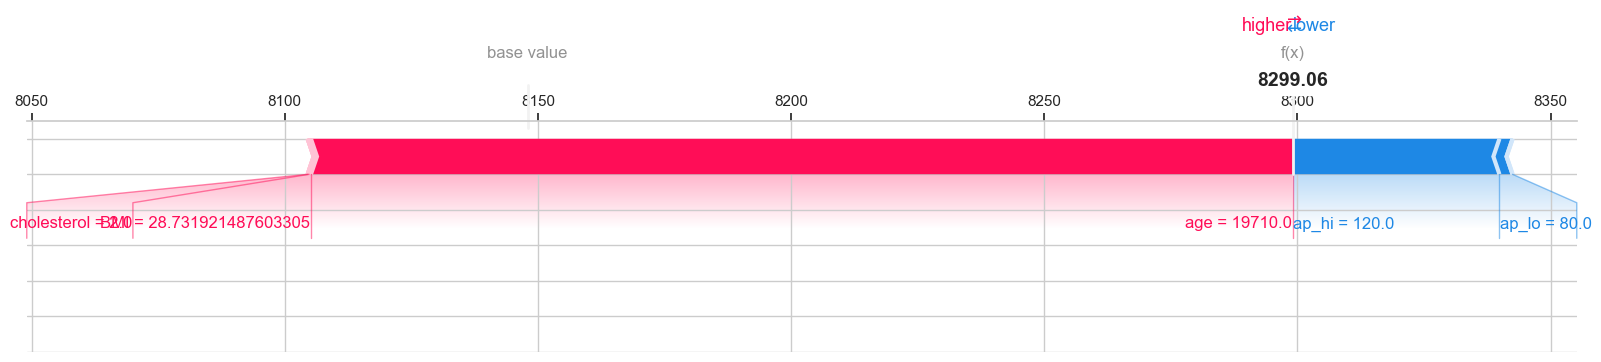

In [19]:
# Initialize the SHAP explainer for the trained logistic regression model
explainer = shap.Explainer(logistic_model.named_steps['logisticregression'], X_train)

# Save the SHAP explainer
with open('shap_explainer_kaggle.pkl', 'wb') as f:
    pickle.dump(explainer, f)

# Compute SHAP values for the test set
shap_values = explainer(X_test)

# Summary plot for feature importance
shap.summary_plot(shap_values, X_test, show=True)

# Bar plot for average absolute SHAP values (overall feature importance)
shap.summary_plot(shap_values, X_test, plot_type='bar', show=True)

# Force plot for a single instance
# Select an instance index to explain
instance_index = 0
# Get the SHAP values for the instance
shap_value_instance = shap_values[instance_index]

# Use SHAP's force plot to visualize
shap.force_plot(
    explainer.expected_value,
    shap_value_instance.values,
    X_test.iloc[instance_index],
    matplotlib=True
)

In [20]:
data.head()


,age,gender,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
id,,,,,,,,,,,
0,18393,1,110,80,1,1,0,0,1,0,21.967120
1,20228,0,140,90,3,1,0,0,1,1,34.927679
2,18857,0,130,70,3,1,0,0,0,1,23.507805
3,17623,1,150,100,1,1,0,0,1,1,28.710479
4,17474,0,100,60,1,1,0,0,0,0,23.011177


In [21]:
data.cholesterol.nunique()

3

In [22]:
data.iloc[0]

age            18393.00000
gender             1.00000
ap_hi            110.00000
ap_lo             80.00000
cholesterol        1.00000
gluc               1.00000
smoke              0.00000
alco               0.00000
active             1.00000
cardio             0.00000
BMI               21.96712
Name: 0, dtype: float64